In [81]:
import warnings
warnings.filterwarnings("ignore")

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [83]:
vocab_size = 10000 

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [84]:
max_len = 50

X_train = pad_sequences(X_train, maxlen=max_len)
X_test  = pad_sequences(X_test, maxlen=max_len)

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM,GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
def build_rnn():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=64, input_length=50),
        SimpleRNN(64),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def build_lstm():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=64, input_length=50),
        LSTM(64),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model
def build_gru():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128, input_length=50),
        GRU(128),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model
# Store models in list
models = [
    ("RNN", build_rnn()),
    ("LSTM", build_lstm()),
    ("GRU",build_gru() )
]

In [86]:
histories = {}

for name, model in models:
    print(f"\n Training {name} model...\n")
    
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    early_stop=EarlyStopping(
        monitor='val_loss',
          patience=3,
            restore_best_weights=True
    )
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop]   
    )
    
    histories[name] = history


 Training RNN model...

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6846 - loss: 0.5651 - val_accuracy: 0.7980 - val_loss: 0.4477
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8622 - loss: 0.3285 - val_accuracy: 0.7876 - val_loss: 0.4563
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9456 - loss: 0.1476 - val_accuracy: 0.7788 - val_loss: 0.7059
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9814 - loss: 0.0542 - val_accuracy: 0.7764 - val_loss: 0.8288

 Training LSTM model...

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7437 - loss: 0.4984 - val_accuracy: 0.8072 - val_loss: 0.4130
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8572 - loss: 0.3337 - val_accuracy: 0.8172 - val_loss: 0.4147
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8928 - loss: 0.2620 - val_accuracy: 0.8068 - val_loss: 0.4225
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/st

In [87]:
for name, model in models:
    print(f"\n Evaluating {name} model:")
    loss, acc = model.evaluate(X_test, y_test)
    print(f"{name} Accuracy: {acc:.4f}")


 Evaluating RNN model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8050 - loss: 0.4322
RNN Accuracy: 0.8050

 Evaluating LSTM model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8132 - loss: 0.4070
LSTM Accuracy: 0.8132

 Evaluating GRU model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8142 - loss: 0.4038
GRU Accuracy: 0.8142


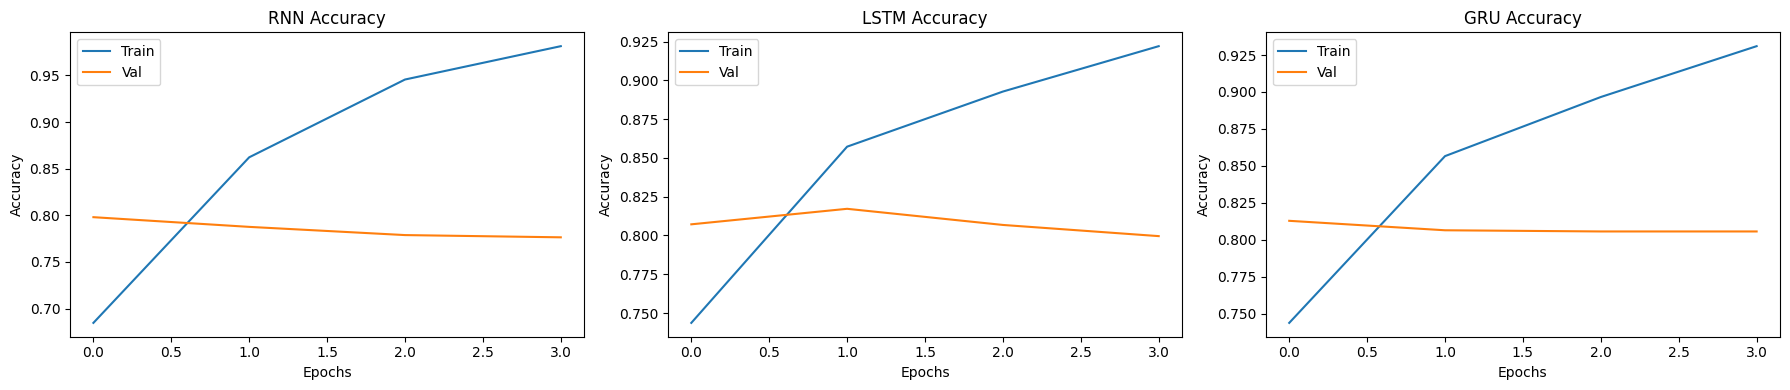

In [88]:
import matplotlib.pyplot as plt

n = len(histories)

plt.figure(figsize=(6*n, 4))  # adjust width dynamically

for i, (name, history) in enumerate(histories.items(), 1):
    plt.subplot(1, n, i)
    
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    
    plt.title(f'{name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Val'])

plt.tight_layout()
plt.show()

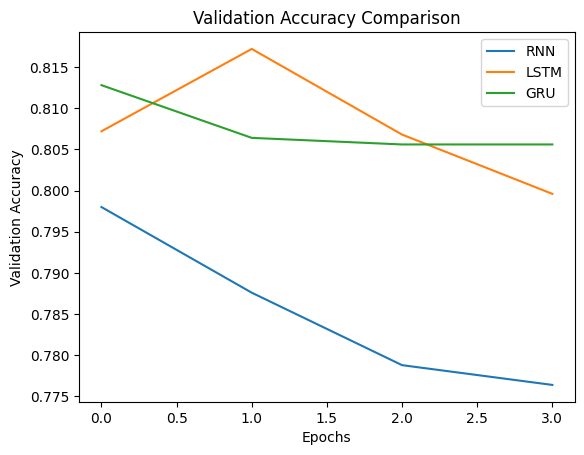

In [89]:
plt.figure()

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.show()

In [90]:
# Load word index
word_index = imdb.get_word_index()

# Shift indices (VERY IMPORTANT)
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2

# Convert text → sequence
def text_to_sequence(text):
    words = text.lower().split()
    return [word_index.get(word, 2) for word in words]

# Predict function
def predict_imdb(text, model):
    seq = text_to_sequence(text)
    padded = pad_sequences([seq], maxlen=50)
    
    pred = model.predict(padded)
    
    return "Positive" if pred[0][0] > 0.5 else "Negative"

In [91]:
print(predict_imdb("This movie was absolutely amazing", models[1][1]))
print(predict_imdb("Worst film I have ever seen", models[2][1]))
print(predict_imdb("The story was boring and slow", models[0][1]))
# model [0][1]->rnn
# model [1][1]->lstm
# model [2][1]->gru

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Positive
